In [1596]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1597]:
df = pd.read_csv("../data/dataset-umkm-modified-old.csv")
df.head()

,id_umkm,nama_usaha,jenis_usaha,tenaga_kerja_perempuan,tenaga_kerja_laki_laki,aset,omset,marketplace,kapasitas_produksi,status_legalitas,...,biaya_karyawan,jumlah_pelanggan,Unnamed: 14,Unnamed: 15,rand_num,omset_outlier,omset_trim,Unnamed: 19,aset_baru,aset_baru_2
0,28828567,UD. Alif Pamungkas,Makanan & Minuman,1,56,3321953,9493293,Tokopedia,479,Belum Terdaftar,...,171000000,479,NaN,NaN,0.976518,9493293,9493293,NaN,6058574,3321953.255
1,28828568,UD. Zidanar Panji,Fashion,5,44,4909911,9783071,Bukalapak,464,Terdaftar,...,147000000,464,NaN,NaN,0.151497,9783071,9783071,NaN,9697179,4909911.428
2,28828569,UD. Winda Jayengprana,Makanan & Minuman,74,51,2442627,8572021,Website Sendiri,383,Belum Terdaftar,...,375000000,383,NaN,NaN,0.922861,8572021,8572021,NaN,53067,2442626.613
3,28828570,UD. Damaris Satria,Perusahaan,89,5,5401350,7898700,Website Sendiri,986,Belum Terdaftar,...,282000000,986,NaN,NaN,0.103956,7898700,7898700,NaN,19194812,5401349.915
4,28828571,UD. Qasya Wiratama,Fashion,91,59,3593331,9148899,Lazada,314,Belum Terdaftar,...,450000000,314,NaN,NaN,0.242525,9148899,9148899,NaN,4383426,3593330.937


In [1598]:
np.random.seed(42)
n = len(df)
df['efficiency'] = np.random.lognormal(mean=0, sigma=0.4, size=n)

In [1599]:
df['aset_sim'] = (
    df['omset'] / df['efficiency']
    + np.random.normal(0, 2_500_000, size=n)
)

In [1600]:
df['aset_sim'] = df['aset_sim'].clip(lower=1_000_000)

In [1601]:
df[['aset_sim', 'omset']].corr()

,aset_sim,omset
aset_sim,1.000000,0.721777
omset,0.721777,1.000000


In [1602]:
df.head()

,id_umkm,nama_usaha,jenis_usaha,tenaga_kerja_perempuan,tenaga_kerja_laki_laki,aset,omset,marketplace,kapasitas_produksi,status_legalitas,...,Unnamed: 14,Unnamed: 15,rand_num,omset_outlier,omset_trim,Unnamed: 19,aset_baru,aset_baru_2,efficiency,aset_sim
0,28828567,UD. Alif Pamungkas,Makanan & Minuman,1,56,3321953,9493293,Tokopedia,479,Belum Terdaftar,...,NaN,NaN,0.976518,9493293,9493293,NaN,6058574,3321953.255,1.219798,6.079294e+06
1,28828568,UD. Zidanar Panji,Fashion,5,44,4909911,9783071,Bukalapak,464,Terdaftar,...,NaN,NaN,0.151497,9783071,9783071,NaN,9697179,4909911.428,0.946196,8.691723e+06
2,28828569,UD. Winda Jayengprana,Makanan & Minuman,74,51,2442627,8572021,Website Sendiri,383,Belum Terdaftar,...,NaN,NaN,0.922861,8572021,8572021,NaN,53067,2442626.613,1.295732,8.114531e+06
3,28828570,UD. Damaris Satria,Perusahaan,89,5,5401350,7898700,Website Sendiri,986,Belum Terdaftar,...,NaN,NaN,0.103956,7898700,7898700,NaN,19194812,5401349.915,1.838982,2.143881e+06
4,28828571,UD. Qasya Wiratama,Fashion,91,59,3593331,9148899,Lazada,314,Belum Terdaftar,...,NaN,NaN,0.242525,9148899,9148899,NaN,4383426,3593330.937,0.910591,8.535507e+06


In [1634]:
df.head()

,id_umkm,nama_usaha,jenis_usaha,tenaga_kerja_perempuan,tenaga_kerja_laki_laki,aset,omset,marketplace,kapasitas_produksi,status_legalitas,...,omset_trim,Unnamed: 19,aset_baru,aset_baru_2,efficiency,aset_sim,total_tk_est,total_tenaga_kerja,lama_usaha,lama_usaha_mod
0,28828567,UD. Alif Pamungkas,Makanan & Minuman,2.0,2.0,3321953,9493293,Tokopedia,479,Belum Terdaftar,...,9493293,NaN,6058574,3321953.255,1.219798,6.079294e+06,4.0,4.0,0.0,-0.238795
1,28828568,UD. Zidanar Panji,Fashion,4.0,3.0,4909911,9783071,Bukalapak,464,Terdaftar,...,9783071,NaN,9697179,4909911.428,0.946196,8.691723e+06,7.0,7.0,4.0,3.979101
2,28828569,UD. Winda Jayengprana,Makanan & Minuman,1.0,2.0,2442627,8572021,Website Sendiri,383,Belum Terdaftar,...,8572021,NaN,53067,2442626.613,1.295732,8.114531e+06,3.0,3.0,0.0,-0.267726
3,28828570,UD. Damaris Satria,Perusahaan,2.0,2.0,5401350,7898700,Website Sendiri,986,Belum Terdaftar,...,7898700,NaN,19194812,5401349.915,1.838982,2.143881e+06,4.0,4.0,3.0,3.305383
4,28828571,UD. Qasya Wiratama,Fashion,0.0,1.0,3593331,9148899,Lazada,314,Belum Terdaftar,...,9148899,NaN,4383426,3593330.937,0.910591,8.535507e+06,1.0,1.0,8.0,8.339360


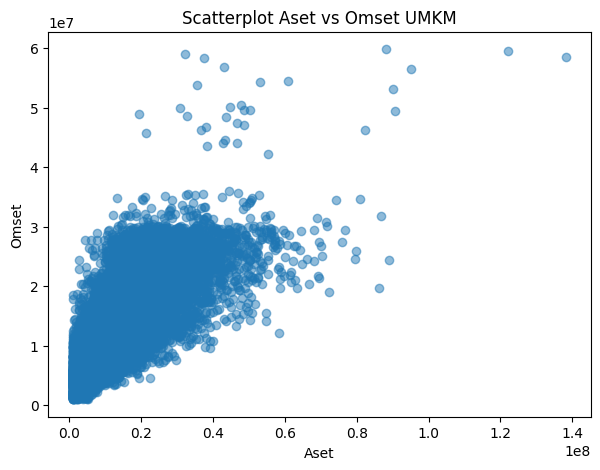

In [1603]:
plt.figure(figsize=(7,5))
plt.scatter(df['aset_sim'], df['omset'], alpha=0.5)
plt.xlabel("Aset")
plt.ylabel("Omset")
plt.title("Scatterplot Aset vs Omset UMKM")
plt.show()

In [1604]:
latent_factor = np.random.uniform(0.5, 1.2, size=len(df))

df["total_tk_est"] = (
    (df["omset"] / 2_000_000) * latent_factor
    + np.random.normal(0, 2, size=len(df))
)

df["total_tk_est"] = (
    df["total_tk_est"]
    .clip(lower=1)   # ⬅️ kunci penting
    .round()
)

In [1605]:
prop_lk = np.random.uniform(0.4, 0.7, size=len(df))

df["tenaga_kerja_laki_laki"] = (
    df["total_tk_est"] * prop_lk
).round()

df["tenaga_kerja_perempuan"] = (
    df["total_tk_est"] - df["tenaga_kerja_laki_laki"]
)

In [1606]:
df["tenaga_kerja_laki_laki"] = pd.to_numeric(
    df["tenaga_kerja_laki_laki"], errors="coerce"
)

df["tenaga_kerja_perempuan"] = pd.to_numeric(
    df["tenaga_kerja_perempuan"], errors="coerce"
)

In [1607]:
df["total_tenaga_kerja"] = (
    df["tenaga_kerja_laki_laki"] +
    df["tenaga_kerja_perempuan"]
)

In [1608]:
df[["total_tenaga_kerja", "omset"]].corr()

,total_tenaga_kerja,omset
total_tenaga_kerja,1.000000,0.764546
omset,0.764546,1.000000


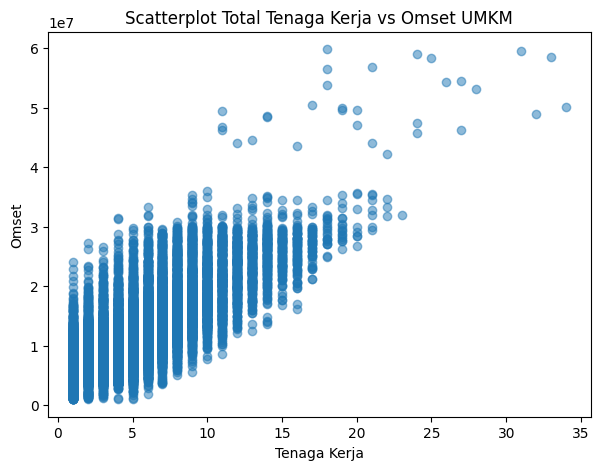

In [1609]:
plt.figure(figsize=(7,5))
plt.scatter(df['total_tenaga_kerja'], df['omset'], alpha=0.5)
plt.xlabel("Tenaga Kerja")
plt.ylabel("Omset")
plt.title("Scatterplot Total Tenaga Kerja vs Omset UMKM")
plt.show()

In [1610]:
# Pastikan tahun_berdiri bertipe numerik
df["tahun_berdiri"] = pd.to_numeric(df["tahun_berdiri"], errors="coerce")

In [1611]:
# Normalisasi omset (0–1)
omset_norm = (df["omset"] - df["omset"].min()) / (
    df["omset"].max() - df["omset"].min()
)

In [1612]:
# Lama usaha dibentuk secara probabilistik
df["lama_usaha"] = (
    1
    + (omset_norm * 20)              # efek lemah lama usaha
    + np.random.normal(0, 4, len(df))  # noise besar
).clip(lower=0).round()

In [1613]:
# Tahun berdiri diturunkan dari lama usaha
current_year = df["tahun_berdiri"].max()
df["tahun_berdiri"] = current_year - df["lama_usaha"]

In [1614]:
df["lama_usaha_mod"] = df["lama_usaha"] + np.random.uniform(-0.4, 0.4, len(df))

Sel-sel dibawah berfungsi menambahkan outlier di pojok kiri atas scatterplot.

In [1615]:
# ambil 2% data dengan omset tertinggi
top_omset_idx = df["omset"].nlargest(int(0.02 * len(df))).index

# dari mereka, pilih sebagian untuk "usaha muda"
young_idx = np.random.choice(
    top_omset_idx,
    size=int(0.5 * len(top_omset_idx)),
    replace=False
)

# set lama usaha jadi sangat pendek (0–7 tahun)
df.loc[young_idx, "lama_usaha_mod"] = np.random.uniform(
    0, 10, size=len(young_idx)
)

In [1616]:
df[["lama_usaha_mod", "omset"]].corr()

,lama_usaha_mod,omset
lama_usaha_mod,1.000000,0.476949
omset,0.476949,1.000000


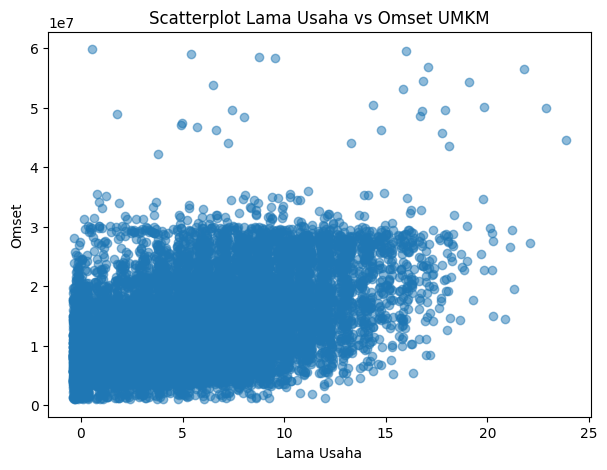

In [1617]:
plt.figure(figsize=(7,5))
plt.scatter(df['lama_usaha_mod'], df['omset'], alpha=0.5)
plt.xlabel("Lama Usaha")
plt.ylabel("Omset")
plt.title("Scatterplot Lama Usaha vs Omset UMKM")
plt.show()

BQ3

In [1618]:
bq3_cols = [
    "status_legalitas",
    "omset",
    "laba"
]

df_bq3 = df[bq3_cols].copy()

In [1619]:
df_bq3 = df_bq3[
    df_bq3["status_legalitas"].isin(["Terdaftar", "Belum Terdaftar"])
]

In [1620]:
df_bq3["omset"] = pd.to_numeric(df_bq3["omset"], errors="coerce")
df_bq3["laba"]  = pd.to_numeric(df_bq3["laba"], errors="coerce")

In [1621]:
df_bq3["laba"] = df_bq3["laba"].round().astype(int)

In [1622]:
high_omset_threshold = df_bq3["omset"].quantile(0.75)

In [1623]:
mask_candidate = (
    (df_bq3["status_legalitas"] == "Belum Terdaftar") &
    (df_bq3["omset"] >= high_omset_threshold)
)

In [1624]:
candidate_idx = df_bq3[mask_candidate].index

np.random.seed(42)  # agar reproducible
to_switch = np.random.choice(
    candidate_idx,
    size=int(len(candidate_idx) * 0.5),  # 50%
    replace=False
)

df_bq3.loc[to_switch, "status_legalitas"] = "Terdaftar"

In [1625]:
high_laba_threshold = df_bq3["laba"].quantile(0.75)

In [1626]:
mask_candidate_laba = (
    (df_bq3["status_legalitas"] == "Belum Terdaftar") &
    (df_bq3["laba"] >= high_laba_threshold)
)

In [1627]:
candidate_idx_laba = df_bq3[mask_candidate_laba].index

np.random.seed(123)  # beda seed dari omset boleh
to_switch_laba = np.random.choice(
    candidate_idx_laba,
    size=int(len(candidate_idx_laba) * 0.4),
    replace=False
)

df_bq3.loc[to_switch_laba, "status_legalitas"] = "Terdaftar"

Kode untuk memodifikasi laba

In [1628]:
np.random.seed(42)

# Margin dasar
margin = np.zeros(len(df_bq3))

mask_legal = df_bq3["status_legalitas"] == "Terdaftar"
margin[mask_legal] = np.random.normal(0.5, 0.25, mask_legal.sum())

mask_nonlegal = df_bq3["status_legalitas"] == "Belum Terdaftar"
margin[mask_nonlegal] = np.random.normal(0.25, 0.2, mask_nonlegal.sum())

# Batasi margin agar masuk akal
margin = np.clip(margin, -0.4, 0.3)

# Hitung laba baru
df_bq3["laba"] = df_bq3["omset"] * margin

In [1629]:
df_bq3["laba"] += np.random.normal(
    0, 1_000_000, size=len(df_bq3)
)

In [1630]:
median_performance = (
    df_bq3
    .groupby("status_legalitas")[["omset", "laba"]]
    .median()
)

median_performance

,omset,laba
status_legalitas,,
Belum Terdaftar,11274230.0,2.191377e+06
Terdaftar,13270976.0,3.660480e+06


C:\Users\User\AppData\Local\Temp\ipykernel_46540\3749076470.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


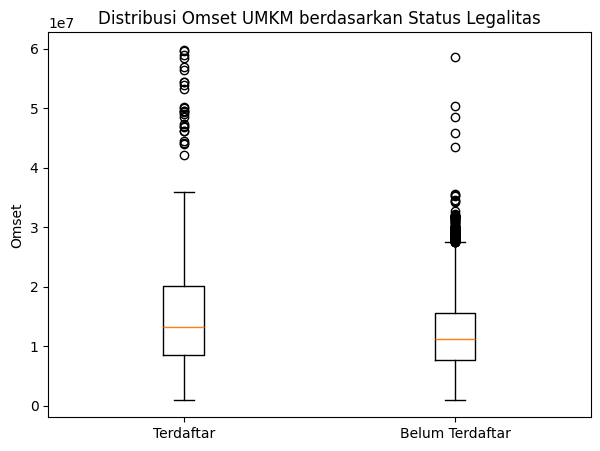

In [1631]:
plt.figure(figsize=(7, 5))
plt.boxplot(
    [df_bq3[df_bq3["status_legalitas"] == "Terdaftar"]["omset"],
     df_bq3[df_bq3["status_legalitas"] == "Belum Terdaftar"]["omset"]],
    labels=["Terdaftar", "Belum Terdaftar"],
    showfliers=True
)

plt.ylabel("Omset")
plt.title("Distribusi Omset UMKM berdasarkan Status Legalitas")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_46540\1818917269.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


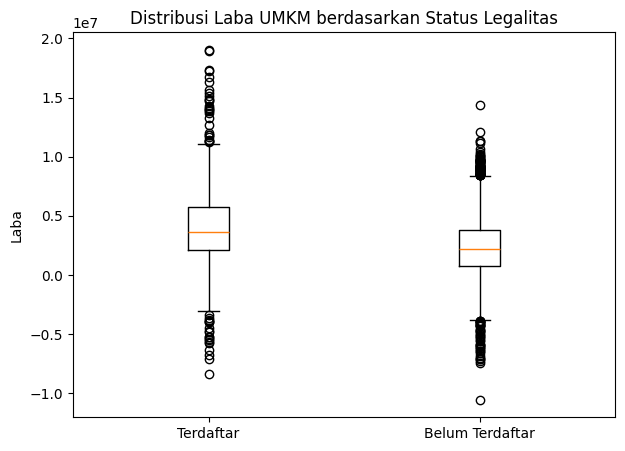

In [1632]:
plt.figure(figsize=(7, 5))
plt.boxplot(
    [df_bq3[df_bq3["status_legalitas"] == "Terdaftar"]["laba"],
     df_bq3[df_bq3["status_legalitas"] == "Belum Terdaftar"]["laba"]],
    labels=["Terdaftar", "Belum Terdaftar"],
    showfliers=True
)

plt.ylabel("Laba")
plt.title("Distribusi Laba UMKM berdasarkan Status Legalitas")
plt.show()

TODO: Kode untuk menyimpan data modifikasi di bawah masih menggunakan df, dan bukan data yang sudah dipisah (df_bq3). Perbaiki kode agar menyimpan hasil SEMUA modifikasi.

In [1633]:
df.to_csv("../data/dataset-umkm-simulated.csv", index=False)
df_bq3.to_csv("../data/dataset-umkm-simulated-bq3.csv", index=False)